Dataset loaded successfully
Current Directory: C:\Users\karan
CSV file created at: C:\Users\karan\mnist_small.csv

Running experiment...
Training with bottleneck = 16
Training with bottleneck = 32
Training with bottleneck = 64


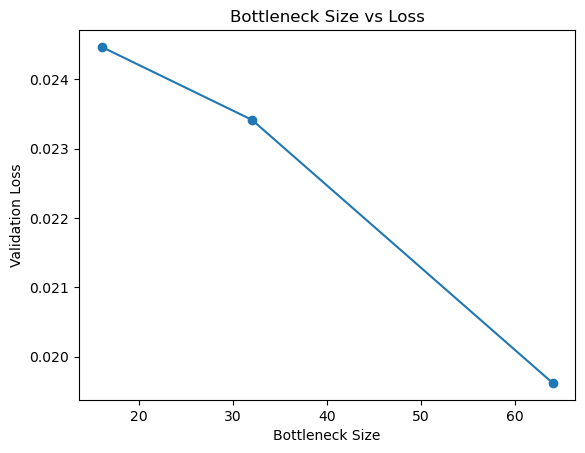


Training final model...


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)          │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_66 (Dense)                     │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_67 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_68 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_69 (Dense)                     │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_70 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_71 (Dense)                     │ (None, 784)                 │         101,136 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0650
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0314
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0238
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0208
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0190
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0174
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0163
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0154
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0145
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0139
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step  


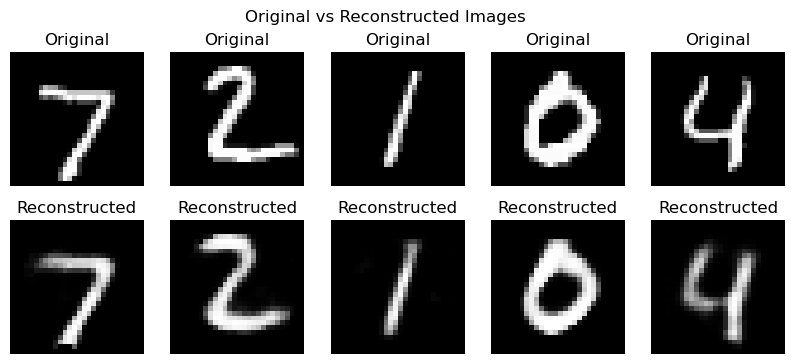

In [5]:
# =========================================
# AUTOENCODER FINAL PROJECT (UPDATED)
# =========================================

import sys
!{sys.executable} -m pip install tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# STEP 3
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat = x_test.reshape(len(x_test), 784)

print("Dataset loaded successfully")

# STEP 4
df = pd.DataFrame(x_train_flat)
df.insert(0, "label", y_train)

print("Current Directory:", os.getcwd())

file_path = os.path.join(os.getcwd(), "mnist_small.csv")
df.head(1000).to_csv(file_path, index=False)

print("CSV file created at:", file_path)

# STEP 5
def build_model(size):
    input_layer = Input(shape=(784,))
    
    x = Dense(128, activation='relu')(input_layer)
    x = Dense(64, activation='relu')(x)
    x = Dense(size, activation='relu')(x)
    x = Dense(64, activation='relu')(x)
    x = Dense(128, activation='relu')(x)
    output = Dense(784, activation='sigmoid')(x)
    
    model = Model(input_layer, output)
    model.compile(optimizer='adam', loss='mse')
    
    return model

# STEP 6
sizes = [16, 32, 64]
loss_values = []

print("\nRunning experiment...")

for size in sizes:
    print("Training with bottleneck =", size)
    
    model = build_model(size)
    
    history = model.fit(
        x_train_flat, x_train_flat,
        epochs=3,
        batch_size=256,
        validation_data=(x_test_flat, x_test_flat),
        verbose=0
    )
    
    loss_values.append(history.history['val_loss'][-1])

# SAVE GRAPH
plt.figure()
plt.plot(sizes, loss_values, marker='o')
plt.title("Bottleneck Size vs Loss")
plt.xlabel("Bottleneck Size")
plt.ylabel("Validation Loss")
plt.savefig("graph.png")   
plt.show()

# STEP 7
print("\nTraining final model...")

autoencoder = build_model(32)

autoencoder.summary()

autoencoder.fit(
    x_train_flat, x_train_flat,
    epochs=10,
    batch_size=256
)

# STEP 8
decoded = autoencoder.predict(x_test_flat)

plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')
    
    plt.subplot(2,5,i+6)
    plt.imshow(decoded[i].reshape(28,28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.suptitle("Original vs Reconstructed Images")

plt.savefig("reconstruction.png")  
plt.show()